<a href="https://colab.research.google.com/github/yiftachsa/AI-Advanced/blob/main/Scaled_Dot_Product_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing Scaled dot-product attention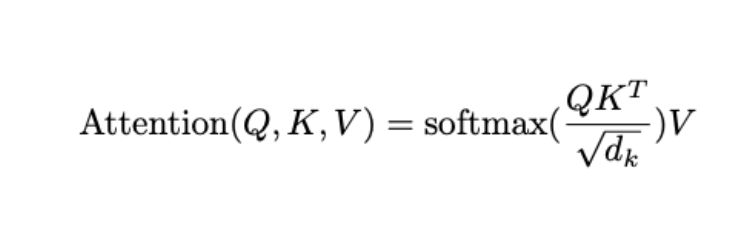

In [ ]:
import tensorflow as tf

def scaled_dot_product_attention(Q, K, V, masked=False):
    """
    Q, K, V: tensors of shape (batch_size, seq_len_q, d_k)
    Returns: attention output, attention weights
    """
    d_k = tf.cast(tf.shape(K)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True)  # (batch_size, seq_len, seq_len) (m, m)
    scores /= tf.math.sqrt(d_k)



    weights = tf.nn.softmax(scores, axis=-1)    # attention weights (batch_size, seq_len, seq_len)
    output = tf.matmul(weights, V)              # (seq_len,)*(batch_size, seq_len, d_v) --> (batch_size, seq_len, d_v)
    return output, weights


In [ ]:

    # Causal mask: shape (1, m, m)
    seq_len = tf.shape(scores)[-1]
    causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)  # Lower triangle incl. diagonal
    causal_mask = tf.where(causal_mask == 0, tf.constant(-1e9, dtype=scores.dtype), 0.0)  # -inf for future
    # Apply
    masked_scores = scores + causal_mask

    # Softmax and attention
    weights = tf.nn.softmax(masked_scores, axis=-1)
    output = tf.matmul(weights, V)
    return output, weights


In [ ]:
batch_size = 2
seq_len = 4
d_k = 8
Q = tf.random.normal(shape=(batch_size, seq_len, d_k))
K = tf.random.normal(shape=(batch_size, seq_len, d_k))
V = tf.random.normal(shape=(batch_size, seq_len, d_k))

output, weights = scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)    # (2, 4, 8)
print("Weights shape:", weights.shape)  # (2, 4, 4)


Output shape: (2, 4, 8)
Weights shape: (2, 4, 4)


Masked dot product attention - Causality mask

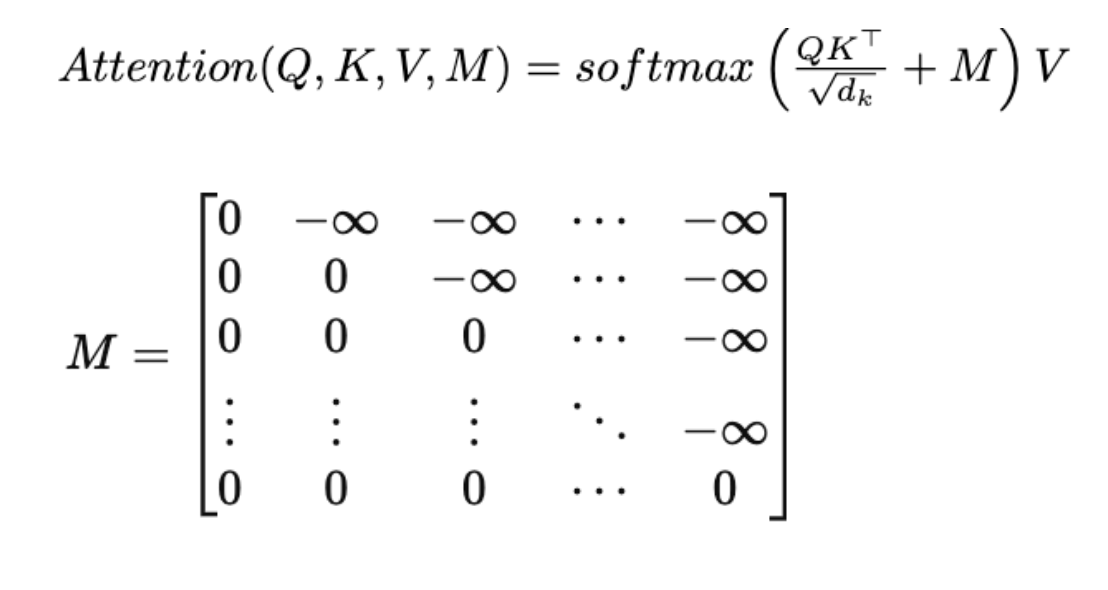

In [ ]:
import tensorflow as tf

def masked_scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention with causal masking.
    Q, K, V: shape (batch_size, seq_len, d_k)
    Returns: output and attention weights
    """
    d_k = tf.cast(tf.shape(K)[-1], tf.float32)
    scores = tf.matmul(Q, K, transpose_b=True)  # (batch_size, seq_len, seq_len) (m, m)
    scores /= tf.math.sqrt(d_k)

    # Causal mask: shape (1, m, m)
    seq_len = tf.shape(scores)[-1]
    print(f"seq_len: {seq_len}")
    causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)  # Lower triangle incl. diagonal
    # print(f"causal_mask: {causal_mask}")
    causal_mask = tf.where(causal_mask == 0, tf.constant(-1e9, dtype=scores.dtype), 0.0)  # -inf for future
    # print(f"causal_mask: {causal_mask}")


    # Apply
    masked_scores = scores + causal_mask

    # Softmax and attention
    weights = tf.nn.softmax(masked_scores, axis=-1)
    output = tf.matmul(weights, V)
    return output, weights


In [ ]:
batch_size = 2
seq_len = 4
d_k = 8
Q = tf.random.normal(shape=(batch_size, seq_len, d_k))
K = tf.random.normal(shape=(batch_size, seq_len, d_k))
V = tf.random.normal(shape=(batch_size, seq_len, d_k))

output, weights = masked_scaled_dot_product_attention(Q, K, V)

print("Output shape:", output.shape)    # (2, 4, 8)
print("Weights shape:", weights.shape)  # (2, 4, 4)

causal_mask: [[1. 0. 0. 0.]
 [1. 1. 0. 0.]
 [1. 1. 1. 0.]
 [1. 1. 1. 1.]]
causal_mask: [[ 0.e+00 -1.e+09 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00 -1.e+09 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00 -1.e+09]
 [ 0.e+00  0.e+00  0.e+00  0.e+00]]
Output shape: (2, 4, 8)
Weights shape: (2, 4, 4)
